1. Setup environment, github, gitignore and overall project structure, src notebooks, data, DOckerfile, etc.
2. Add setup.py file.
3. Add logging and Exception files.

4. Now the actual project begins:

CLassification task, whether the site is legitimate or phishing. The goal is to classify whether a website URL/webpage is legitimate or phishing (malicious) based on various handcrafted features extracted from the URL and webpage properties.
# Data Taking from MongoDB:

## How data comes in MongoDB?
- ETL Pipelines: (Extract, Transform and Load):

- We have csv dataset in local and we do some basic preprocessing like cleaning and transformation to json (eg) and save it to destination like in MongoDB.
- Data can be coming from anywhere, apis, aws, mysql, internal DBs, etc. So, we should know how to handle it.

- This Extracting from local and doing transformation and loading to mongodb is done in ETL pipeline.


Setup Mongobd Test its connection in the test_data file.

BUild push_data file †o convert csv data to json and push it to mongodb

## Now comes Data Ingestion pipeline:


DataIngestionCOnfig -> DataIngestionPipeline -> DataIngestionArtifacts 

![Screenshot 2026-06-06 at 10.38.49 AM.png](<attachment:Screenshot 2026-06-06 at 10.38.49 AM.png>)

                           
- Added constants in constant folder related to training and ingetsion pipeline and made them accessible through classes in entity folder.
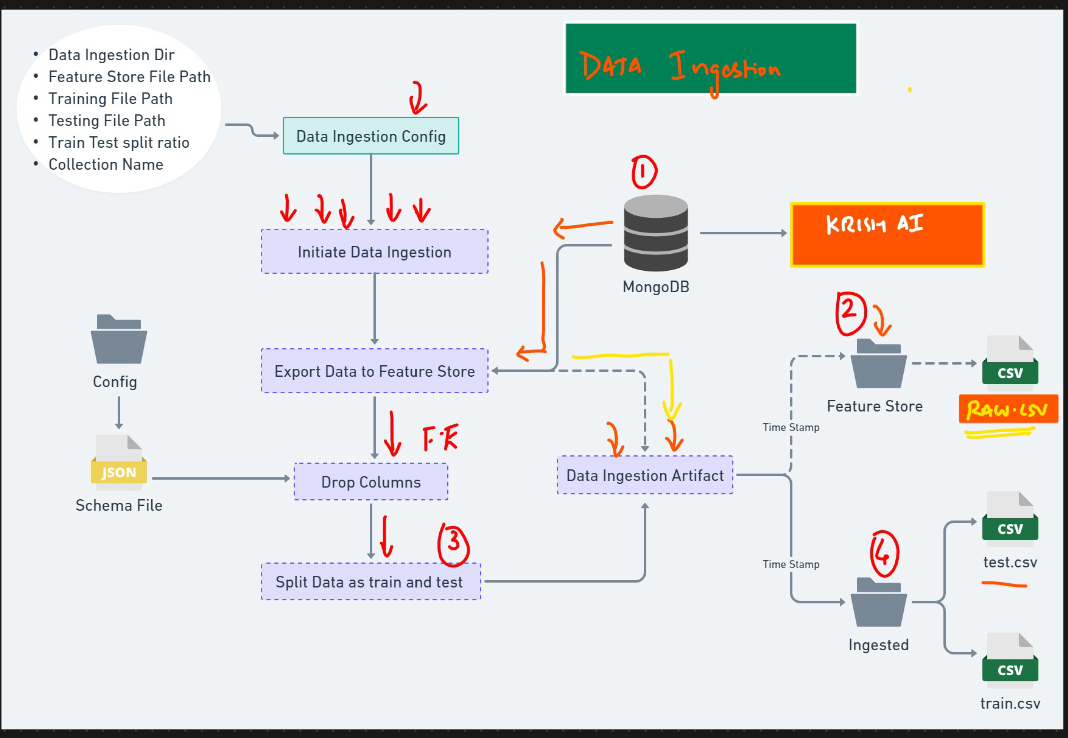

1. Read data from MOngoDB
2. Create Feature store
3. Split Train and test and save it to ingested folder.

- Changed data_ingestion.py file and tested it using main.py file.

# Data Validation:

DataValidationConfig + DataIngestionArtifact -> DataValidationPipeline -> DataValidationComponent
![Screenshot 2026-06-06 at 12.10.35 PM.png](<attachment:Screenshot 2026-06-06 at 12.10.35 PM.png>)


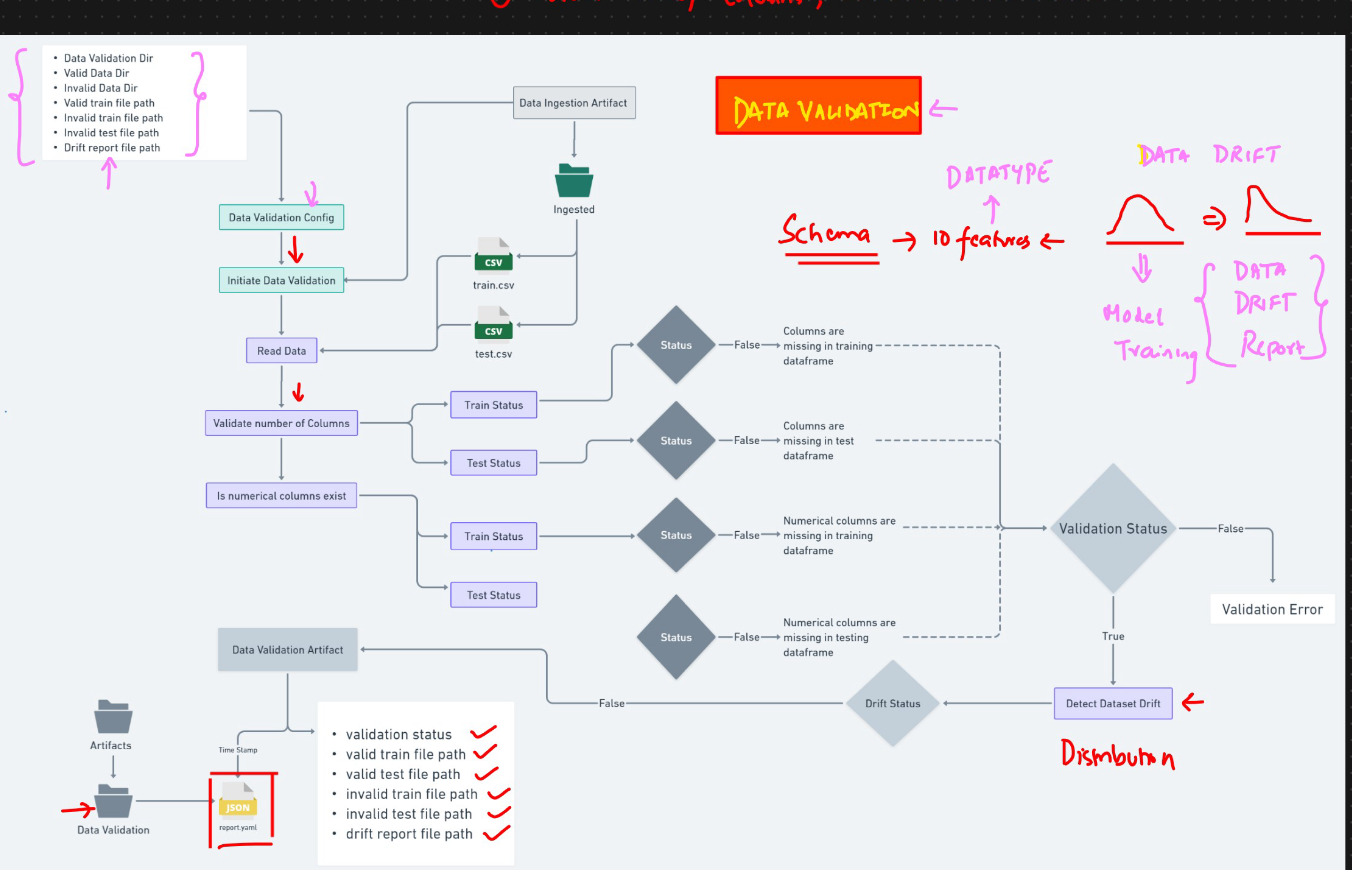

1. SameSchema : done using schema.yaml file to validate the given data schema with the schema defined in this file.
2. DataDrift (scipt.stats -> ks_2samp)
3. Validate Num of Columns , Numerical columns exist or not.


BAsically read train and test data given by ingestion artifact, check it they have same columns and if numerical features exists or not, if anyone is false, validation is failed else if all are true, check dataset drift, if it is false then create datavalidation artifact.


Completely wrote the data validation code and checked it using main.py file 

## Data Transformation

DataValidationArtifact + DataTransformationConfig -> DataTransformationPipeline -> DataTransformationArtifact

![Screenshot 2026-06-07 at 3.10.17 PM.png](<attachment:Screenshot 2026-06-07 at 3.10.17 PM.png>)
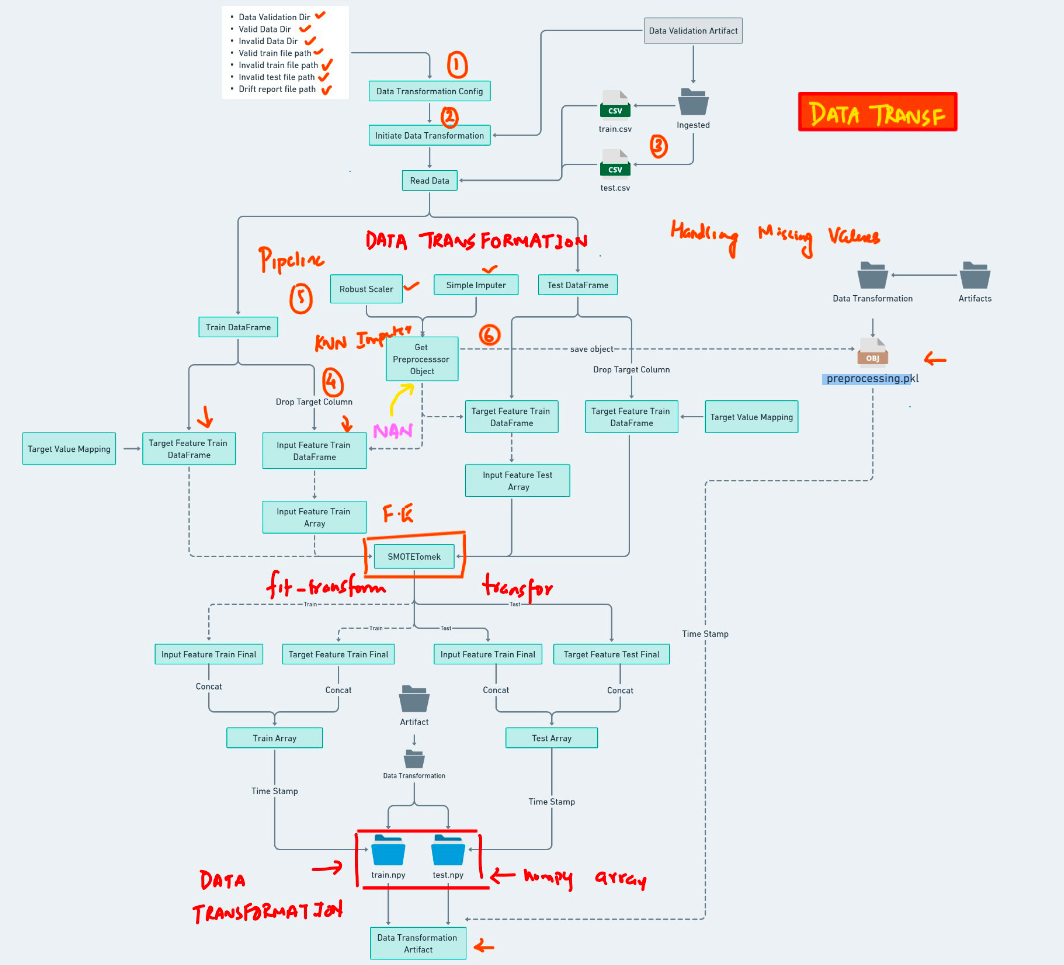

- We have train and test csv from validation artifacts,
- here we have done imputation only as part of data transformation i.e. handling missing values. Dataset was already balanced.
- Separation of traget column is necesaary before doing transformation, after the transformation is done, they are concatenated again.
- We get the final transformed artifacts as .npy file and preprocessor as .pkl file.


## MOdel Trainer

ModelTrainerConfig + DataTransformationArtifact -> Model Trainer Component -> ModelTrainerArtifacts

![Screenshot 2026-06-07 at 4.50.14 PM.png](<attachment:Screenshot 2026-06-07 at 4.50.14 PM.png>)
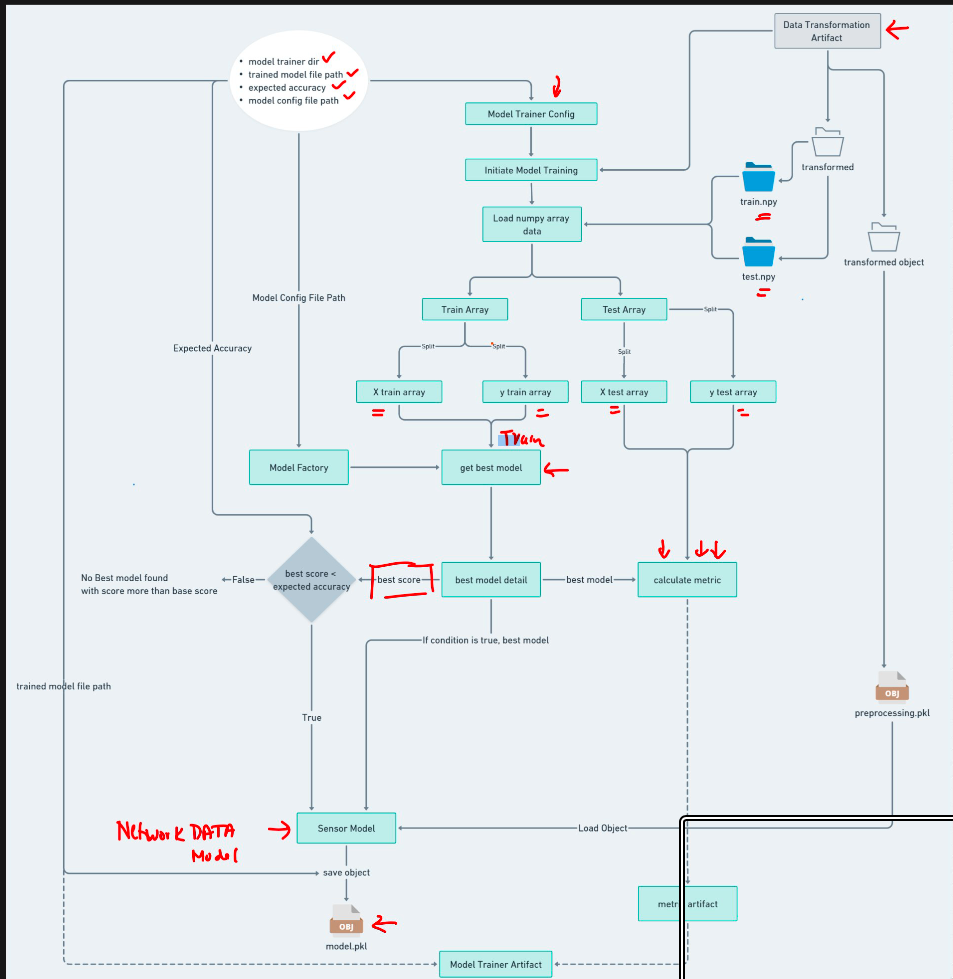

Have trained the model using KNN, SVC, Logistic, RandomFOrest, Adaboost, gradientboost, Decision Tree. Random Forest yields best performance with f1 score of 97%.


### Tracking through MLFlow



- added mlflow tracking with mlflow.start_run() to track locally
- then track through remote repository Dagshub
- 

- Built Training pipeline which includes all of the main.py process but in classes.
- added app.py to faciilitate training through apis and prediction of test data.

## Deployment


- Docker Image -> AWS ECR -> AWS EC2
- Github Actions build CI-CD Pipelines
- Added two functions to save the artifacts to cloud basically to AWS S3 bucket rather than saving them on local.